**TERMINAL ACCESS in COLAB**

In [8]:
#!pip install
#delete ??

In [9]:
!pip install timm

**Importing Requisites**

In [10]:
import torch
import torch.nn as nn
import torchvision
import torchvision.datasets as datasets
import torch.optim as optim
import torchvision.transforms as transforms
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import os
import sys

In [11]:
import torchvision.models as models

In [12]:
import timm

In [17]:
import os

# Define the directory structure
base_dir = 'dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

# Create directories if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Create subdirectories for each class (example: 'class1' and 'class2')
os.makedirs(os.path.join(train_dir, 'class1'), exist_ok=True)
os.makedirs(os.path.join(train_dir, 'class2'), exist_ok=True)
os.makedirs(os.path.join(val_dir, 'class1'), exist_ok=True)
os.makedirs(os.path.join(val_dir, 'class2'), exist_ok=True)


In [18]:
import shutil

# Example of moving files
shutil.move('/content/WhatsApp Image 2024-07-16 at 11.26.58.jpeg', os.path.join(train_dir, 'class1'))
shutil.move('/content/WhatsApp Image 2024-07-16 at 11.29.16.jpeg', os.path.join(val_dir, 'class1'))


'dataset/val/class1/WhatsApp Image 2024-07-16 at 11.29.16.jpeg'

In [19]:
!ls dataset/train/class1  # Check files in class1 of train
!ls dataset/val/class1    # Check files in class1 of val


'WhatsApp Image 2024-07-16 at 11.26.58.jpeg'
'WhatsApp Image 2024-07-16 at 11.29.16.jpeg'


In [23]:
!rm -r dataset/train/.ipynb_checkpoints
!rm -r dataset/val/.ipynb_checkpoints


In [24]:
import os
from torchvision import datasets, transforms
import torch
import torchvision

# Define the transformations for training and validation datasets
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Custom function to filter out non-image directories
def is_valid_file(filename):
    valid_extensions = ('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp')
    return filename.lower().endswith(valid_extensions)

# Load the image datasets
data_dir = 'dataset'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x], is_valid_file=is_valid_file) for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=4) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
print(dataset_sizes)
class_names = image_datasets['train'].classes
print(class_names)

# Load CIFAR-10 datasets
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
trainset_cifar10 = torchvision.datasets.CIFAR10(root='./Data/', train=True, download=True, transform=transform)
testset_cifar10 = torchvision.datasets.CIFAR10(root='./Data/', train=False, download=True, transform=transform)


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


{'train': 1, 'val': 1}
['class1']


100%|██████████| 170498071/170498071 [00:03<00:00, 48478778.64it/s]


Extracting ./Data/cifar-10-python.tar.gz to ./Data/
Files already downloaded and verified


**LOADING DATA**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
print('The Length of Train set is : {} and of Test set is {}'.format(len(train_dir), len(val_dir)))

The Length of Train set is : 22 and of Test set is 20


**Setting hyperparameters**

In [27]:
batch_size = 4
num_epochs = 20

learning_rate = 0.001

In [28]:
train_loader = torch.utils.data.DataLoader(image_datasets['train'], batch_size=4, shuffle=True, num_workers=4)


test_loader = torch.utils.data.DataLoader(image_datasets['val'], batch_size=4, shuffle=True, num_workers=4)


**Making Dictionary assigining label name to labels**

**Lets Plot some of the data - Visualize the Data**

In [29]:
classes = ('airplanes', 'cars', 'birds', 'cats', 'deer', 'dogs', 'frogs', 'horses', 'ships','trucks','humans')

In [30]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

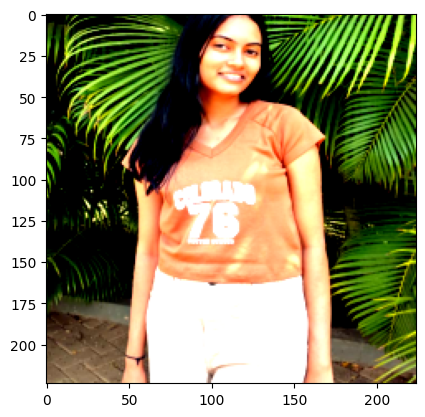

airplanes


In [32]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))

# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(len(labels))))


In [33]:
class my_net(nn.Module):
    def __init__(self):
        super(my_net, self).__init__()

        # Constraints for layer 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride = 1, padding=2)
        self.batch1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2) #default stride is equivalent to the kernel_size

        # Constraints for layer 2
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride = 1, padding=2)
        self.batch2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        # Defining the Linear layer
        self.fc = nn.Linear(32*7*7, 10)

    # defining the network flow
    def forward(self, x):
        # Conv 1
        out = self.conv1(x)
        out = self.batch1(out)
        out = self.relu1(out)

        # Max Pool 1
        out = self.pool1(out)

        # Conv 2
        out = self.conv2(out)
        out = self.batch2(out)
        out = self.relu2(out)

        # Max Pool 2
        out = self.pool2(out)

        out = out.view(out.size(0), -1)
        # Linear Layer
        out = self.fc(out)

        return out

In [34]:

model = my_net()

In [35]:
def set_requires_grad(model):
    for param in model.parameters():
        param.requires_grad = True

**Timm Library**

In [36]:
# Load VGG16 model
model = timm.create_model('vgg16', pretrained=True, num_classes=10)
set_requires_grad(model)

# # Load ResNet50 model
# model = timm.create_model('resnet50', pretrained=True)
# model.fc = nn.Linear(model.fc.in_features, 10)

# # Load InceptionNet model
# model = timm.create_model('inception_v3', pretrained=True)
# model.fc = nn.Linear(model.fc.in_features, 10)

# # Load MobileNetV3 model
# model = timm.create_model('mobilenetv3_large_100', pretrained=True)
# model.classifier = nn.Sequential(
#     nn.Linear(model.classifier.in_features, 1024),
#     nn.Hardswish(),
#     nn.Dropout(p=0.2),
#     nn.Linear(1024, 10)
# )

# # Print model summaries (optional)
# print(vgg16)
# print(alexnet)
# print(resnet50)
# print(inception_v3)
# print(mobilenetv3_large_100)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

In [37]:
model_names = timm.list_models('*vgg16*') #WildCard *
print(*model_names,len(model_names), sep='\n')

vgg16
vgg16_bn
2


**Transfer Learning**

1. Step1 : Freezing the layers
2. Step2 : Changing the final classifier layer to required number of classes.

In [38]:
model.parameters

<bound method Module.parameters of VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (17): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (18): ReLU(inplace=True)
    (19): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (20): ReLU(inplace=True)
    (21): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (22): ReLU(inplace=True)
    (23): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (24): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (25): ReLU(inplace=True)
    (26): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (27): ReLU(inplace=True)
    (28): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (29): ReLU(inplace=True)
    (30): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pre_logits): ConvMlp(
    (fc1): Conv2d(512, 4096, kernel_size=(7, 7), stride=(1, 1))
    (act1): ReLU(inplace=True)
    (drop): Dropout(p=0.0, inplace=False)
    (fc2): Conv2d(4096, 4096, kernel_size=(1, 1), stride=(1, 1))
    (act2): ReLU(inplace=True)
  )
  (head): ClassifierHead(
    (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Flatten(start_dim=1, end_dim=-1))
    (drop): Dropout(p=0.0, inplace=False)
    (fc): Linear(in_features=4096, out_features=10, bias=True)
    (flatten): Identity()
  )
)>

In [39]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [40]:
print(device)

cuda


In [41]:
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

**Defining ``Loss Function`` and ``Optimizer``**

In [42]:
criterion = nn.CrossEntropyLoss().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

**Start training our model**

In [43]:
losses = []

for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if (i+1) % 100 == 0:
            print ('Epoch : %d/%d, Iter : %d/%d,  Loss: %.4f'
                   %(epoch+1, num_epochs, i+1,\
                     len(trainset)//batch_size, loss.item()))

**Alternate Way to Display Progress : Use Tqdm utility (a.k.a progress bar)**

In [44]:
from tqdm import tqdm
from time import sleep


model.train()
for epoch in range(num_epochs):
  with tqdm(train_loader, unit="batch") as tepoch:
    for images, labels in tepoch:
      tepoch.set_description(f"Epoch {epoch+1}")
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs = model(images)
      predictions = outputs.argmax(dim=1, keepdim=True).squeeze()
      loss = criterion(outputs, labels)
      correct = (predictions == labels).sum().item()
      accuracy = correct / batch_size

      loss.backward()
      optimizer.step()

      tepoch.set_postfix(loss=loss.item(), accuracy=100. * accuracy)


Epoch 20: 100%|██████████| 1/1 [00:00<00:00,  4.05batch/s, accuracy=25, loss=0]


**Saving the model**

This will save only model parameters

In [45]:
torch.save(model, 'my_net.pt')

**`Evaluating` the model**

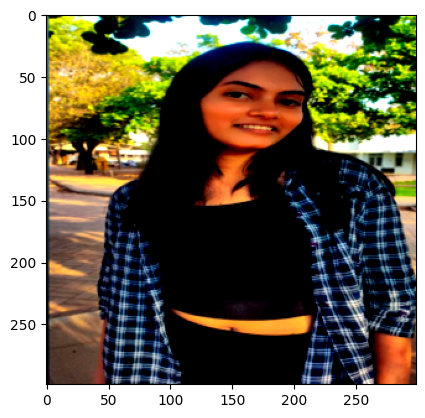

airplanes
Test Accuracy of the model on the 10000 test images: 100.0000 %


In [46]:
from torch.autograd import Variable

correct = 0
total = 0

for images, labels in test_loader:
  images = Variable(images.float())
  images = images.to(device)
  labels = labels.to(device)

  output = model(images)
  _, predicted = torch.max(output.data, 1)

  total += labels.size(0)
  correct += (predicted == labels).sum()

  imshow(torchvision.utils.make_grid(images.to('cpu')))
  # print labels
  print(' '.join(f'{classes[predicted[j]]:5s}' for j in range(0,len(images))))


print('Test Accuracy of the model on the 10000 test images: %.4f %%' % (100 * correct / total))

**Plotting Losses**

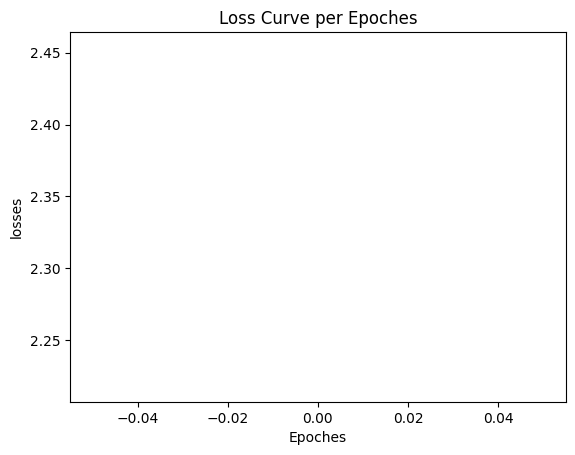

In [47]:
loss = losses[0::100]
plt.xlabel('Epoches')
plt.ylabel('losses')
plt.title('Loss Curve per Epoches')
plt.plot(loss)
plt.show()